#### First Step: Import Libraries
- import numpy, pandas, matplotlib, KNeighborsClassifier from sklearn.neighbors and some metrics

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Second Step: Read csv file
- read the csv file data using pd (pandas)

In [2]:
df = pd.read_csv("heart disease dataset.csv")

#### Third Step: Preview Data
- preview the first 5 rows of data to see the type of the data like categorical and numerical
- also to see the type of output column if discrete or continuous

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


#### Fourth Step: Initialize X
- X is only the input data without the output column

In [4]:
X = df.drop(columns=["target"], axis=1)
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


#### Fifth Step: Initialize Y
- y is only the output column

In [5]:
y = df["target"]
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

#### Sixth Step: Import and Initialize transformers
- based on the data:
    - if we have categorical data import OneHotEncoder to transform them to numerical
    - if we have numerical data import StandardScaler to scale values (so no feature is dominant over the others)

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numerical_transfomer = StandardScaler()

preprocessor = ColumnTransformer ([
    ("StandardScaler", numerical_transfomer, X.columns)
])

#### Seventh Step: fit transform X
- the input must be fit transformed using the transformers to apply transformation

In [7]:
X = preprocessor.fit_transform(X)

#### Eighth Step: split data into training and testing
- we must split data into training and testing
- as a some standards way:
    - training 80%, testing 20%
    - training 70%, testing 30%

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, train_size=0.8, random_state=42)

#### Ninth Step: Better than step 7 (either step 7 either this)

- **but you can skip it now for the hackathon and do 7**

- it is better to transform training and testing like this below instead of fit transform all X 
    - fit transform all X is not a good idea, because the model will see the whole X training and testing
    - fit transform all X can lead to data leakage because:
        - fit_transform calculates the parameters (like mean and variance) from the data and applies the transformation in one step, whereas transform uses those previously learned parameters to transform new data consistently.
    - so we apply fit transform on X_train and transform on X_test

- **Note: Of course you must do transforming but either 7 or 9**

In [9]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

ValueError: Specifying the columns using strings is only supported for dataframes.

#### This is to show you how to do KNN choosing a specific number of neighbors
**Of course we must iterate over k like below and choose the best**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, Y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


##### **Accuracy:** Number of total correct predictions the model got over all predictions.

In [ ]:
y_pred = knn.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9180327868852459


##### **Confusion Matrix:** Table showing correct vs. incorrect predictions for each class.

In [ ]:
confusion_matrix(Y_test, y_pred)

array([[27,  2],
       [ 3, 29]], dtype=int64)

##### **Classification Report:** Summary of precision, recall, F1-score, and support for each class.
- Precision: Of all predicted positives, how many were actually correct.
- Recall: Of all actual positives, how many the model correctly identified.
- F1-score: Harmonic mean of precision and recall, balancing both.
- Support: Number of actual samples for each class in the dataset.

In [ ]:
print(classification_report(Y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.93      0.92        29
           1       0.94      0.91      0.92        32

    accuracy                           0.92        61
   macro avg       0.92      0.92      0.92        61
weighted avg       0.92      0.92      0.92        61



#### Tenth Step: Best way to choose the number of nearest neighbors
1. loop over k from 1 to 21
2. apply KNeighborsClassifier on k
3. fit the model
4. predict using X_test
5. check accuracy
6. add accuracy to the array

In [ ]:
k_values = range(1, 22)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, Y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(Y_test, y_pred)
    accuracies.append(acc)


#### Eleventh Step: Choose best k
1. find best k using maximum accuracy
2. get the best accuracy

In [ ]:
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

#### Twelfth Step: Plot the figure of k
- plot the accuracy of each k and highlight the best

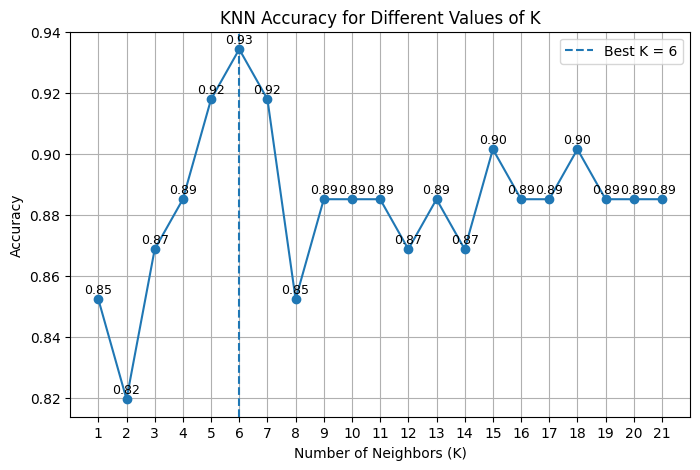

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o')
plt.axvline(best_k, linestyle='--', label=f'Best K = {best_k}')

# show accuracy values on the plot
for k, acc in zip(k_values, accuracies):
    plt.text(k, acc + 0.002, f"{acc:.2f}", ha='center', fontsize=9)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different Values of K")
plt.xticks(k_values)
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print("Best K:", best_k)
print("Best Accuracy:", best_accuracy)

Best K: 6
Best Accuracy: 0.9344262295081968


#### Thirteenth Step: train the model using the best k

In [ ]:
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, Y_train)

,n_neighbors,6
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Fourteenth Step: predict using X_test and print metrics

In [ ]:
y_pred_best = knn_best.predict(X_test)

print("Final Model Accuracy:", accuracy_score(Y_test, y_pred_best))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(Y_test, y_pred_best))

Final Model Accuracy: 0.9344262295081968

Confusion Matrix:
 [[28  1]
 [ 3 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.97      0.93        29
           1       0.97      0.91      0.94        32

    accuracy                           0.93        61
   macro avg       0.93      0.94      0.93        61
weighted avg       0.94      0.93      0.93        61



#### Fifteenth Step: Save actual and Predicted values into a csv file

In [ ]:
pred_df = pd.DataFrame({"Actual":Y_test, "Predicted":y_pred_best})
pred_df.to_csv("heart_disease_actual_vs_predicted_knn.csv", index=False)
pred_df

,Actual,Predicted
179,0,0
228,0,0
111,1,1
246,0,0
60,1,1
...,...,...
249,0,0
104,1,1
300,0,0
193,0,0


#### Sixteenth Step: Try a new unseen data
1. declare the data using array
2. Initialize X_df without target because it contains the columns names before scaling
3. Initialize new_patient_df with the new data and columns names
4. transform the new_patient_df
5. predict the target
6. print result
    - if 1 then heart disease
    - if 0 then no heart disease

In [ ]:
# 1. Provide the new patient data (numerical values matching the dataset features)
# Features order: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]
new_patient = [56, 1, 0, 132, 184, 0, 0, 105, 1, 2.1, 1, 1, 1]

# 2. Get the feature column names (excluding the target) from the original dataframe
# This ensures our new prediction DataFrame has the exact same structure as the training data
X_df = df.drop("target", axis=1)

# 3. Initialize a new DataFrame for the patient with the correct feature names
new_patient_df = pd.DataFrame(
    [new_patient],
    columns=X_df.columns
)

# 4. Transform/Scale the new data using the pre-fitted preprocessor
# We use .transform() (NOT fit_transform) to apply the exact same scaling used during training
new_patient_scaled = preprocessor.transform(new_patient_df)

# 5. Use the trained KNN model to predict the class
prediction = knn_best.predict(new_patient_scaled)

# 6. Check the prediction result and print a human-readable message
# Class 1 = Heart Disease detected, Class 0 = No Heart Disease
if prediction[0] == 1:
    print("Prediction: Heart Disease")
else:
    print("Prediction: No Heart Disease")

Prediction: No Heart Disease


#### Seventeenth Step: export the model and preprocessor
1. import joblib
2. export the model and preprocessor into pkl form using joblib.dump to use them in streamlit

In [ ]:
import joblib
joblib.dump(knn_best, "knn_model.pkl")
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']